# 02 — Descriptive Statistics

> **Key question**: Which Pokémon are strong enough to be considered for the best possible team?

We analyse the **BST (Base Stat Total)** to define competitiveness thresholds, then break down the statistical role of each primary type.

**Prerequisite**: run `01_data_loading_cleaning.ipynb` first.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import pickle

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC',
}

with open('../data/pokemon_processed.pkl', 'rb') as f:
    df = pickle.load(f)
print(f'Data loaded: {df.shape[0]} Pokémon')

Data loaded: 1025 Pokémon


## 1. BST Distribution — How competitive is each Pokémon?

The BST is the sum of all 6 base stats — the simplest measure of raw power. We define 4 tiers:
- **Weak** (< 350): rarely useful in competitive play
- **Average** (350–450): situational use
- **Strong** (450–550): solid team candidates
- **Elite** (> 550): pseudo-legendaries & legendaries


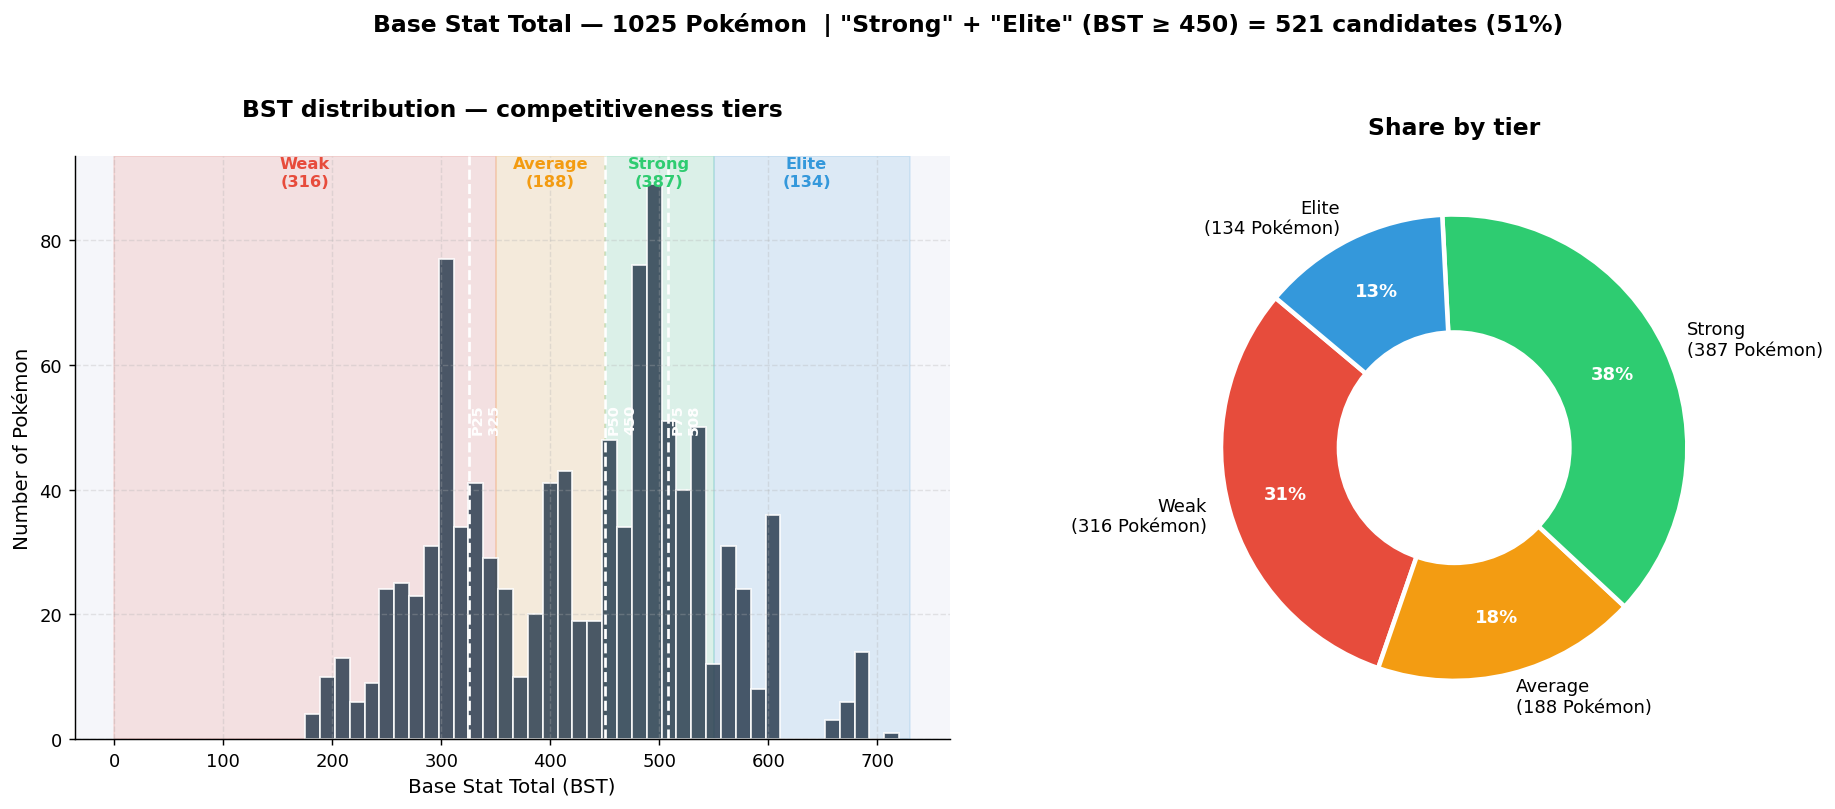

In [2]:
bst = df['bst']
tiers = [
    (0,   350, '#E74C3C', 'Weak'),
    (350, 450, '#F39C12', 'Average'),
    (450, 550, '#2ECC71', 'Strong'),
    (550, 900, '#3498DB', 'Elite'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for lo, hi, col, label in tiers:
    count = ((bst >= lo) & (bst < hi)).sum()
    ax.axvspan(lo, min(hi, bst.max() + 10), alpha=0.13, color=col)
    mid = (lo + min(hi, bst.max())) / 2
    ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
            f'{label}\n({count})', ha='center', va='top',
            fontsize=9, fontweight='bold', color=col,
            transform=ax.get_xaxis_transform())

ax.hist(bst, bins=40, color='#2C3E50', edgecolor='white', alpha=0.85)

for pct in [25, 50, 75]:
    v = bst.quantile(pct / 100)
    ax.axvline(v, color='white', linestyle='--', linewidth=1.5)
    ax.text(v + 2, ax.get_ylim()[1] * 0.55,
            f'P{pct}\n{v:.0f}', fontsize=8, color='white',
            fontweight='bold', rotation=90, va='center')

ax.set_title('BST distribution — competitiveness tiers', pad=22)
ax.set_xlabel('Base Stat Total (BST)')
ax.set_ylabel('Number of Pokémon')

ax2 = axes[1]
tier_data = [(label, ((bst >= lo) & (bst < hi)).sum(), col)
             for lo, hi, col, label in tiers]
wedge_props = {'edgecolor': 'white', 'linewidth': 2.5}
wedges, texts, autos = ax2.pie(
    [n for _, n, _ in tier_data],
    labels=[f"{l}\n({n} Pokémon)" for l, n, _ in tier_data],
    colors=[c for _, _, c in tier_data],
    autopct='%1.0f%%', startangle=140,
    wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'fontsize': 10}
)
for at in autos:
    at.set_color('white')
    at.set_fontweight('bold')
ax2.add_artist(plt.Circle((0, 0), 0.5, color='white'))
ax2.set_title('Share by tier', pad=12)

plt.suptitle(
    f'Base Stat Total — {len(df)} Pokémon  '
    f'| "Strong" + "Elite" (BST ≥ 450) = {(bst >= 450).sum()} candidates ({(bst >= 450).mean()*100:.0f}%)',
    fontsize=13, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

## 2. Top 15 Pokémon by BST — Priority candidates


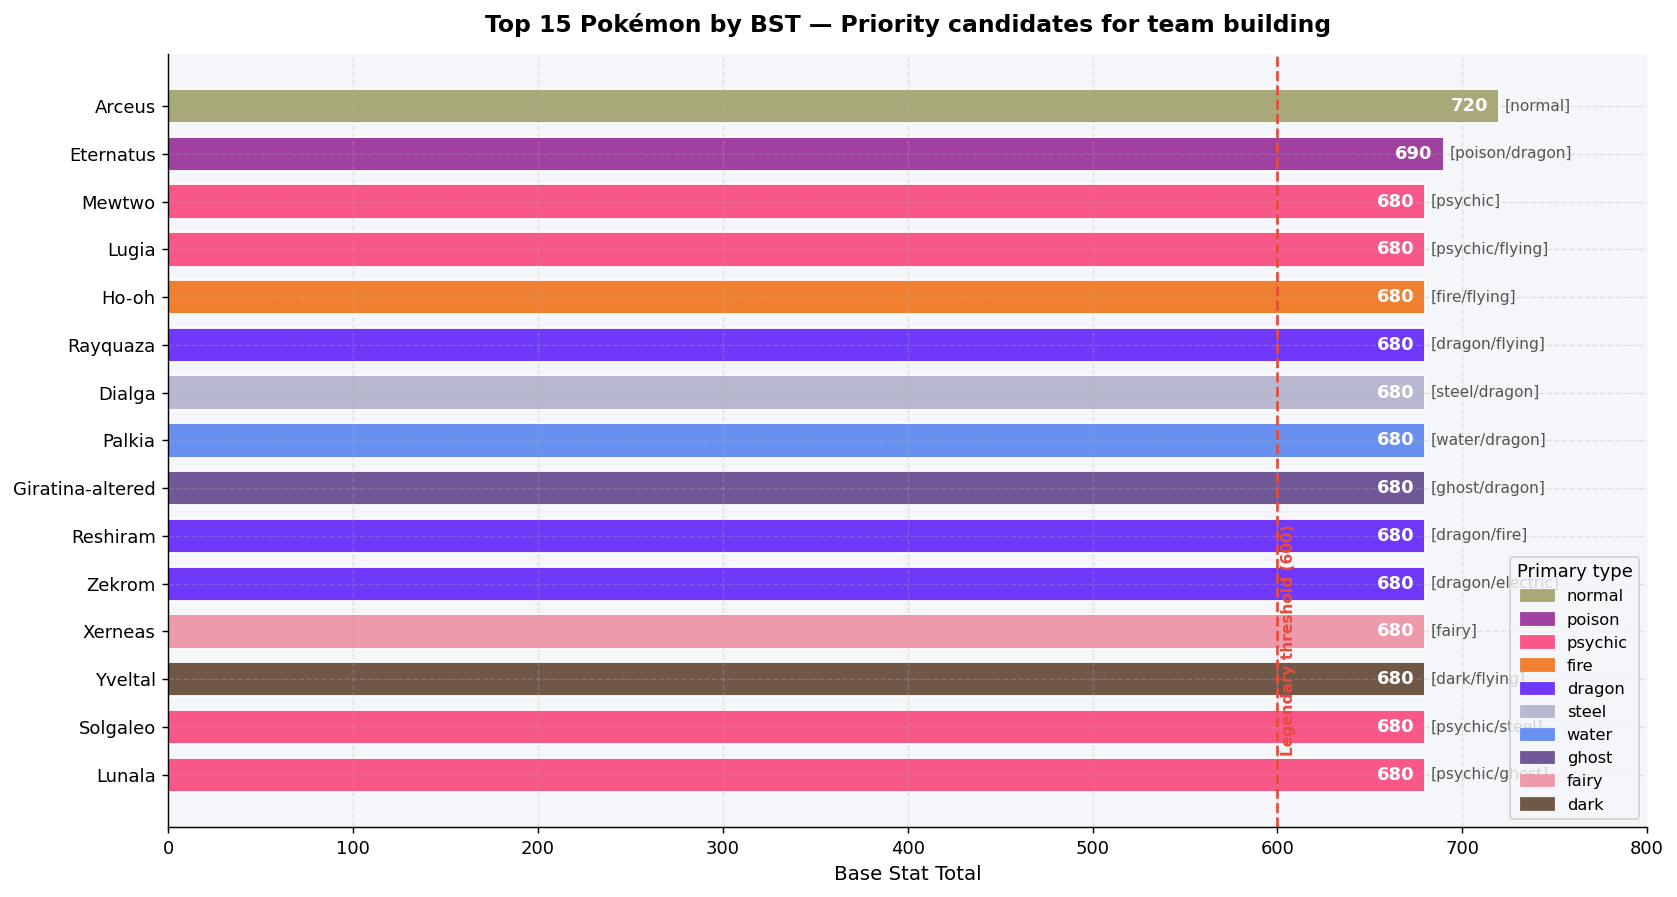

In [3]:
top15 = df.nlargest(15, 'bst').copy().reset_index(drop=True)
top15['name_cap'] = top15['name'].str.capitalize()
top15['type_label'] = top15.apply(
    lambda r: r['type1'] if pd.isna(r['type2']) else f"{r['type1']}/{r['type2']}", axis=1
)

fig, ax = plt.subplots(figsize=(13, 7))
colors = [TYPE_COLORS.get(t, '#888') for t in top15['type1']]
bars = ax.barh(top15['name_cap'][::-1], top15['bst'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=1, height=0.72)

for bar, (_, row) in zip(bars, top15[::-1].iterrows()):
    ax.text(bar.get_width() - 6, bar.get_y() + bar.get_height() / 2,
            f"{int(row['bst'])}", va='center', ha='right',
            fontsize=10, color='white', fontweight='bold')
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f"[{row['type_label']}]", va='center', fontsize=8.5, color='#555')

ax.axvline(600, color='#E74C3C', linestyle='--', linewidth=1.5)
ax.text(602, 0.4, 'Legendary threshold (600)',
        rotation=90, va='bottom', fontsize=8.5, color='#E74C3C', fontweight='bold')
ax.set_title('Top 15 Pokémon by BST — Priority candidates for team building', pad=12)
ax.set_xlabel('Base Stat Total')
ax.set_xlim(0, max(top15['bst']) + 80)
handles = [mpatches.Patch(color=TYPE_COLORS.get(t, '#888'), label=t)
           for t in top15['type1'].unique()]
ax.legend(handles=handles, title='Primary type', fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 3. Statistical roles by type — Who attacks? Who defends? Who's fast?

A complementary team needs **different roles**: a tank, a physical sweeper, a special attacker, a fast support, etc.
Choosing types with contrasting profiles is key to strategic complementarity.


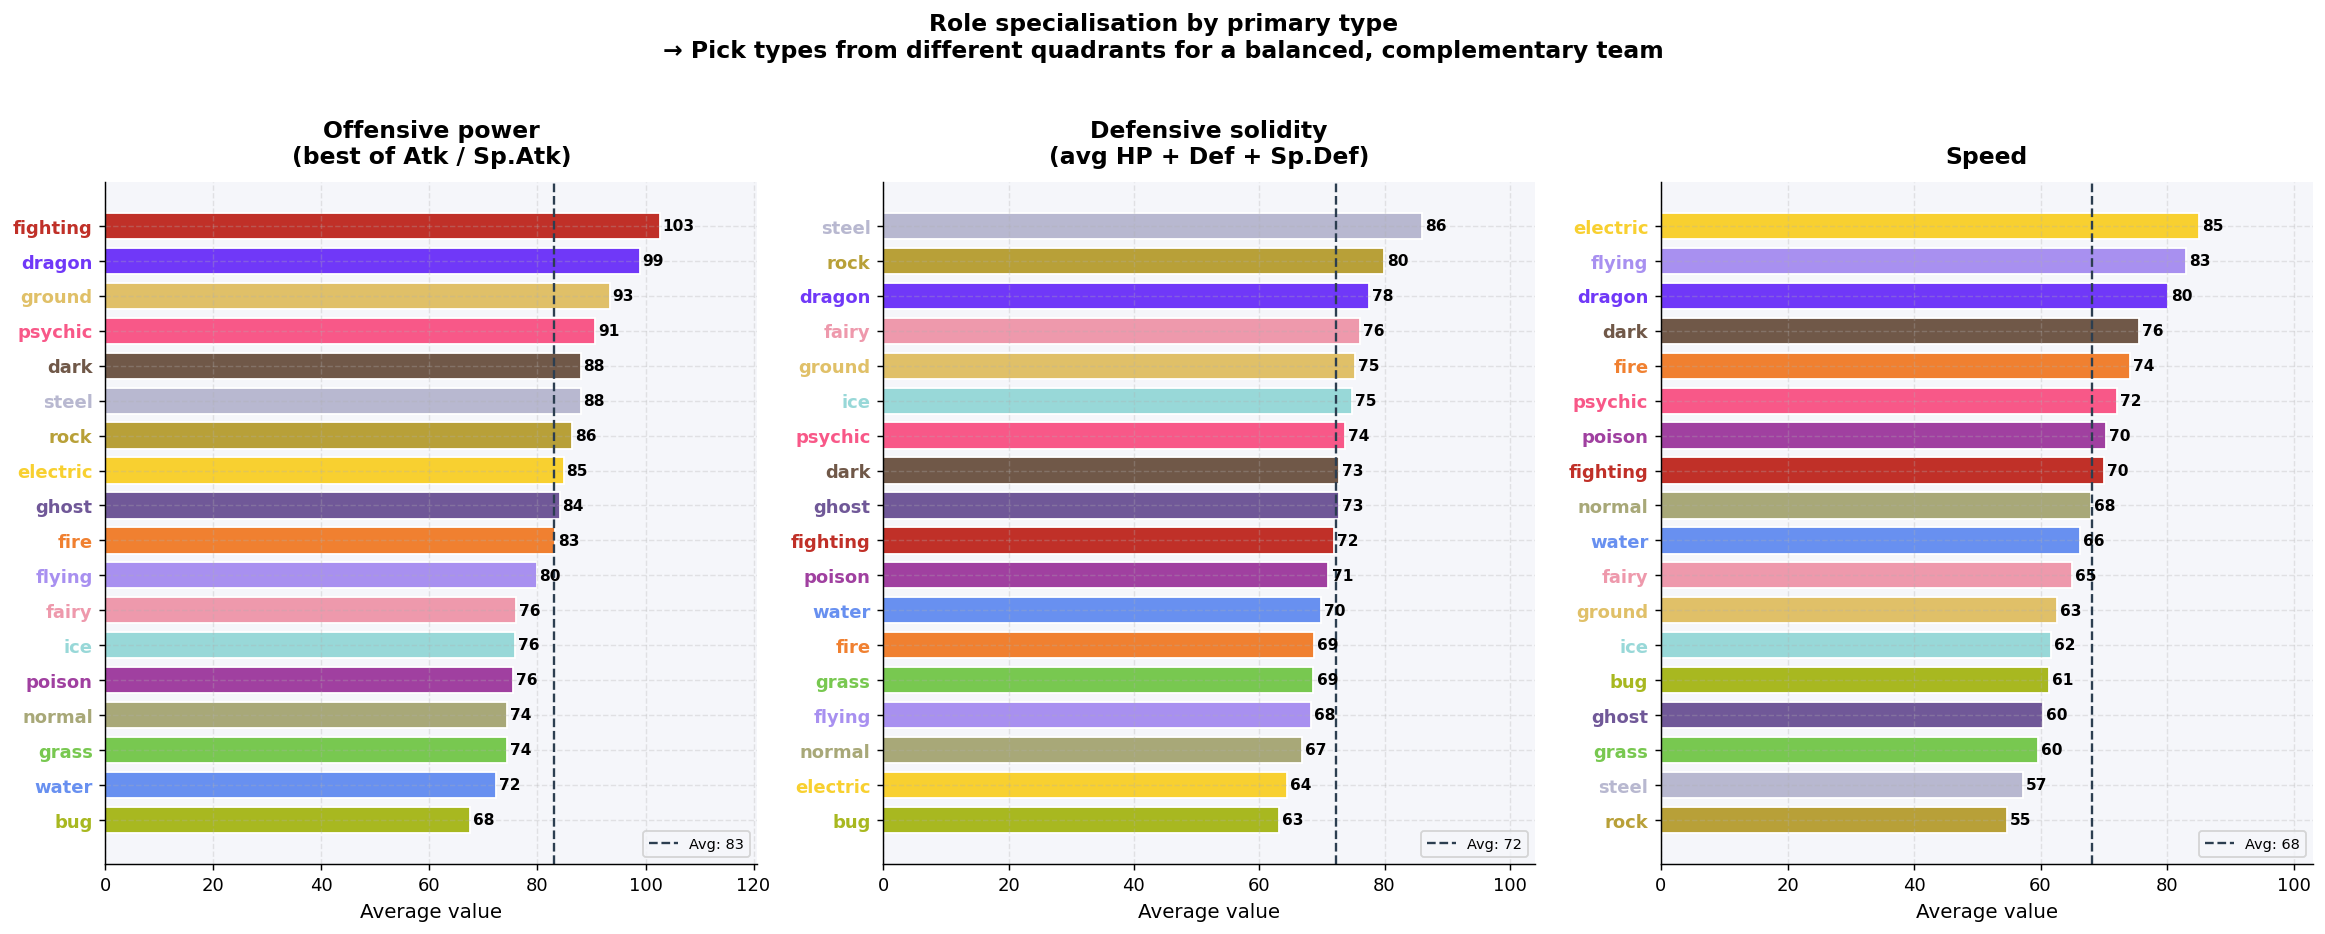

In [4]:
type_means = df.groupby('type1')[STATS].mean()
type_means['offense'] = type_means[['attack', 'special-attack']].max(axis=1)
type_means['defense'] = type_means[['defense', 'special-defense', 'hp']].mean(axis=1)
type_means['speed']   = type_means['speed']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, col, title, color in [
    (axes[0], 'offense', 'Offensive power\n(best of Atk / Sp.Atk)',     '#E74C3C'),
    (axes[1], 'defense', 'Defensive solidity\n(avg HP + Def + Sp.Def)', '#3498DB'),
    (axes[2], 'speed',   'Speed',                                        '#F39C12'),
]:
    data = type_means[col].sort_values(ascending=True)
    cols = [TYPE_COLORS.get(t, '#888') for t in data.index]
    bars = ax.barh(data.index, data.values, color=cols, edgecolor='white', height=0.75)

    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}', va='center', fontsize=8.5, fontweight='bold')
    for i, t in enumerate(data.index):
        ax.get_yticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
        ax.get_yticklabels()[i].set_fontweight('bold')

    ax.axvline(data.mean(), color='#2C3E50', linestyle='--', linewidth=1.3,
               label=f'Avg: {data.mean():.0f}')
    ax.set_title(title, pad=10)
    ax.set_xlabel('Average value')
    ax.set_xlim(0, data.max() + 18)
    ax.legend(fontsize=8)

plt.suptitle(
    'Role specialisation by primary type\n'
    '→ Pick types from different quadrants for a balanced, complementary team',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()